Compare the numebr of escapes and number pof homings

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dill as pickle
from loguru import logger
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.rcParams.update({
    "font.size": 14,
    "font.family": "Arial",
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# Function to find all session directories
def find_all_sessions(base_path="Z:/Jasmine_Laurence/Experimental_Data"):
    """Find all session directories in the base path"""
    session_paths = []
    
    # Look for JAL directories
    mouse_dirs = glob.glob(os.path.join(base_path, "JAL*"))
    
    for mouse_dir in mouse_dirs:
        # Find all session directories within each mouse directory
        sessions = glob.glob(os.path.join(mouse_dir, "*"))
        for session in sessions:
            # Check if it's a directory and contains processed_data
            if os.path.isdir(session) and os.path.exists(os.path.join(session, "processed_data")):
                session_paths.append(session)
    
    return session_paths

# Function to load homings object
def load_homings_object(session_path):
    """Load homings object from a session"""
    homings_path = os.path.join(session_path, "processed_data", "homings", "homings_obj.pkl")
    
    if os.path.exists(homings_path):
        try:
            with open(homings_path, "rb") as f:
                return pickle.load(f)
        except Exception as e:
            logger.warning(f"Error loading homings object from {session_path}: {e}")
    
    return None

# Function to load escapes object
def load_escapes_object(session_path):
    """Load escapes object from a session, checking multiple possible paths"""
    possible_paths = [
        os.path.join(session_path, "processed_data", "escapes", "escapes_obj.pkl"),
        os.path.join(session_path, "processed_data", "escape", "escapes_obj.pkl"),
        os.path.join(session_path, "processed_data", "escapes_obj.pkl")
    ]
    
    for path in possible_paths:
        if os.path.exists(path):
            try:
                with open(path, "rb") as f:
                    return pickle.load(f)
            except Exception as e:
                logger.warning(f"Error loading escapes object from {path}: {e}")
    
    return None

# Function to count homings and escapes
def count_homings_and_escapes(session_path):
    """Count the number of homings and escapes in a session"""
    session_name = os.path.basename(session_path)
    mouse_name = os.path.basename(os.path.dirname(session_path))
    
    # Load homings and escapes objects
    homings_obj = load_homings_object(session_path)
    escapes_obj = load_escapes_object(session_path)
    
    # Count homings if object exists
    num_homings = 0
    if homings_obj is not None and hasattr(homings_obj, "onset_frames"):
        num_homings = len(homings_obj.onset_frames)
    
    # Count escapes if object exists
    num_escapes = 0
    if escapes_obj is not None and hasattr(escapes_obj, "escape_onset_frames"):
        num_escapes = len(escapes_obj.escape_onset_frames)
    
    return {
        "session_path": session_path,
        "session_name": session_name,
        "mouse_name": mouse_name,
        "num_homings": num_homings,
        "num_escapes": num_escapes
    }

# Main function to analyze all sessions
def analyze_homings_vs_escapes():
    """Analyze homings vs escapes across all sessions and create a box plot"""
    # Find all session paths
    logger.info("Finding all session paths...")
    session_paths = find_all_sessions()
    logger.info(f"Found {len(session_paths)} session paths")
    
    # Count homings and escapes for each session
    logger.info("Counting homings and escapes...")
    results = []
    for session_path in session_paths:
        results.append(count_homings_and_escapes(session_path))
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    # Print summary statistics
    print("Summary statistics:")
    print(f"Total sessions: {len(df)}")
    print(f"Sessions with homings: {len(df[df.num_homings > 0])}")
    print(f"Sessions with escapes: {len(df[df.num_escapes > 0])}")
    print(f"Average homings per session: {df.num_homings.mean():.2f}")
    print(f"Average escapes per session: {df.num_escapes.mean():.2f}")
    
    # Create the box plot
    logger.info("Creating box plot...")
    plot_data = pd.melt(df[["session_name", "num_homings", "num_escapes"]], 
                        id_vars=["session_name"], 
                        value_vars=["num_homings", "num_escapes"],
                        var_name="Behavior Type", value_name="Count")
    
    # Rename variables for better plot labels
    plot_data["Behavior Type"] = plot_data["Behavior Type"].replace({
        "num_homings": "Homings",
        "num_escapes": "Escapes"
    })
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    
    # Create box plot
    ax = sns.boxplot(x="Behavior Type", y="Count", data=plot_data, 
                    palette=["lightblue", "lightcoral"])
    
    # Add swarm plot to show individual points
    sns.swarmplot(x="Behavior Type", y="Count", data=plot_data, 
                color="dimgrey", alpha=0.7)
    
    # Add statistical annotation
    from scipy.stats import wilcoxon
    stat_result = wilcoxon(df.num_homings, df.num_escapes)
    p_value = stat_result.pvalue
    
    if p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = "n.s."
    
    y_max = plot_data["Count"].max() * 1.1
    plt.plot([0, 1], [y_max, y_max], 'k-', linewidth=1.5)
    plt.text(0.5, y_max * 1.05, significance, ha='center', va='center', fontsize=18)
    
    # Add labels and formatting
    plt.title("Comparison of Homings vs Escapes Across Sessions", fontweight="bold")
    plt.ylabel("Count per Session")
    plt.xlabel("")
    
    # Remove top and right spines
    sns.despine()
    
    # Save the figure
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, "homings_vs_escapes.eps"), format='eps', bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(save_path, "homings_vs_escapes.png"), format='png', bbox_inches='tight', dpi=300)
    
    plt.show()
    
    # Return the DataFrame for further analysis
    return df

# Run the analysis
homings_vs_escapes_df = analyze_homings_vs_escapes()

2025-07-16 15:34:37.754 | INFO     | __main__:analyze_homings_vs_escapes:106 - Finding all session paths...
2025-07-16 15:34:37.927 | INFO     | __main__:analyze_homings_vs_escapes:108 - Found 47 session paths
2025-07-16 15:34:37.927 | INFO     | __main__:analyze_homings_vs_escapes:111 - Counting homings and escapes...
2025-07-16 15:34:43.242 | INFO     | __main__:analyze_homings_vs_escapes:128 - Creating box plot...


Summary statistics:
Total sessions: 47
Sessions with homings: 35
Sessions with escapes: 38
Average homings per session: 46.60
Average escapes per session: 6.57


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [2]:
def analyze_homings_vs_escapes():
    """Analyze homings vs escapes across all sessions and create a bar plot for publication"""
    # Find all session paths
    logger.info("Finding all session paths...")
    session_paths = find_all_sessions()
    logger.info(f"Found {len(session_paths)} session paths")
    
    # Count homings and escapes for each session
    logger.info("Counting homings and escapes...")
    results = []
    for session_path in session_paths:
        results.append(count_homings_and_escapes(session_path))
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    # Print summary statistics
    print("Summary statistics:")
    print(f"Total sessions: {len(df)}")
    print(f"Sessions with homings: {len(df[df.num_homings > 0])}")
    print(f"Sessions with escapes: {len(df[df.num_escapes > 0])}")
    print(f"Average homings per session: {df.num_homings.mean():.2f}")
    print(f"Average escapes per session: {df.num_escapes.mean():.2f}")
    
    # Calculate statistics for bar plot
    behavior_types = ["Homings", "Escapes"]
    means = [df.num_homings.mean(), df.num_escapes.mean()]
    sems = [df.num_homings.sem(), df.num_escapes.sem()]
    
    # Set publication-quality plot parameters
    plt.rcParams.update({
        "font.size": 16,
        "font.family": "Arial",
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "savefig.dpi": 300,
        "figure.dpi": 150
    })
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create bar plot with error bars
    bars = ax.bar(
        np.arange(len(behavior_types)), 
        means, 
        yerr=sems,
        width=0.6, 
        capsize=8, 
        color=['#4878D0', '#EE854A'], 
        edgecolor='black',
        linewidth=1.5,
        error_kw={'elinewidth': 1.5, 'capthick': 1.5}
    )
    
    # Add individual data points
    for i, behavior in enumerate(behavior_types):
        if behavior == "Homings":
            data = df.num_homings
        else:
            data = df.num_escapes
        
        # Add jittered points
        jitter = np.random.normal(0, 0.05, size=len(data))
        ax.scatter(
            i + jitter, 
            data, 
            color='dimgrey', 
            alpha=0.5, 
            s=40, 
            zorder=3
        )
    
    # Add statistical annotation
    from scipy.stats import wilcoxon
    stat_result = wilcoxon(df.num_homings, df.num_escapes)
    p_value = stat_result.pvalue
    
    if p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = "n.s."
    
    # Calculate position for significance bar
    y_max = max(means) + max(sems) + (max(means) * 0.2)
    ax.plot([0, 1], [y_max, y_max], 'k-', linewidth=2)
    ax.text(0.5, y_max * 1.05, significance, ha='center', va='center', fontsize=20, fontweight='bold')
    
    # Add exact p-value
    p_text = f"p = {p_value:.3f}" if p_value >= 0.001 else "p < 0.001"
    ax.text(0.5, y_max * 0.92, p_text, ha='center', va='center', fontsize=14)
    
    # Set axis labels and title
    ax.set_xticks(np.arange(len(behavior_types)))
    ax.set_xticklabels(behavior_types, fontweight='bold')
    ax.set_ylabel("Count per Session", fontweight='bold')
    ax.set_title("Comparison of Homings vs Escapes", fontweight="bold")
    
    # Set y-axis limits with some padding
    ax.set_ylim(0, y_max * 1.15)
    
    # Add value labels on top of bars
    for i, (bar, mean) in enumerate(zip(bars, means)):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            mean + sems[i] + (max(means) * 0.03),
            f"{mean:.1f}",
            ha='center',
            va='bottom',
            fontsize=14,
            fontweight='bold'
        )
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=6)
    
    # Add grid lines for y-axis only
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    
    # Tight layout to maximize figure space
    plt.tight_layout()
    
    # Save the figure with high resolution
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, "homings_vs_escapes_barplot.eps"), format='eps', bbox_inches='tight')
    plt.savefig(os.path.join(save_path, "homings_vs_escapes_barplot.png"), format='png', bbox_inches='tight')
    plt.savefig(os.path.join(save_path, "homings_vs_escapes_barplot.pdf"), format='pdf', bbox_inches='tight')
    
    plt.show()
    
    # Return the DataFrame for further analysis
    return df

In [3]:
analyze_homings_vs_escapes()

2025-07-16 15:34:51.548 | INFO     | __main__:analyze_homings_vs_escapes:4 - Finding all session paths...
2025-07-16 15:34:51.722 | INFO     | __main__:analyze_homings_vs_escapes:6 - Found 47 session paths
2025-07-16 15:34:51.723 | INFO     | __main__:analyze_homings_vs_escapes:9 - Counting homings and escapes...
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Summary statistics:
Total sessions: 47
Sessions with homings: 35
Sessions with escapes: 38
Average homings per session: 46.60
Average escapes per session: 6.57


,session_path,session_name,mouse_name,num_homings,num_escapes
0,Z:/Jasmine_Laurence/Experimental_Data\JAL004\0...,004_baseline_2023_08_17T13_41_44,JAL004,3,1
1,Z:/Jasmine_Laurence/Experimental_Data\JAL004\0...,004_flipppuf19sept_2023_09_19T14_10_56,JAL004,76,18
2,Z:/Jasmine_Laurence/Experimental_Data\JAL004\0...,004_flip_2023_09_03T12_04_16,JAL004,67,8
3,Z:/Jasmine_Laurence/Experimental_Data\JAL004\0...,004_flip_puff2_2023_09_11T09_32_25,JAL004,43,7
4,Z:/Jasmine_Laurence/Experimental_Data\JAL004\0...,004_mush1_2023_08_22T13_13_41,JAL004,0,0
5,Z:/Jasmine_Laurence/Experimental_Data\JAL004\J...,JAL004_flip_rotated_2023_08_28T09_36_04,JAL004,31,3
6,Z:/Jasmine_Laurence/Experimental_Data\JAL003\0...,003_003puftrotato3_2023_09_07T12_23_47,JAL003,130,23
7,Z:/Jasmine_Laurence/Experimental_Data\JAL003\0...,003_baseline_2023_08_17T08_16_46,JAL003,5,3
8,Z:/Jasmine_Laurence/Experimental_Data\JAL003\0...,003_flippuff2_2023_09_04T13_38_31,JAL003,89,13
9,Z:/Jasmine_Laurence/Experimental_Data\JAL003\0...,003_flip_1Sept_2023_09_01T16_23_39,JAL003,109,6


In [8]:
def analyze_homings_trend_by_mouse():
    """
    Analyze whether the number of homings increases across sessions for each mouse.
    Creates a multi-panel plot showing trends for each individual mouse.
    Excludes JAL001 and JAL002 from the analysis.
    """
    # Find all session paths
    logger.info("Finding all session paths...")
    session_paths = find_all_sessions()
    logger.info(f"Found {len(session_paths)} session paths")
    
    # Count homings and escapes for each session
    logger.info("Counting homings and escapes...")
    results = []
    for session_path in session_paths:
        session_data = count_homings_and_escapes(session_path)
        
        # Extract date information from session path
        session_name = session_data["session_name"]
        try:
            # First look for ISO format date without parsing time components
            import re
            # Extract just the date part to avoid timezone issues
            date_match = re.search(r'(\d{4})[-_](\d{2})[-_](\d{2})', session_name)
            if date_match:
                year, month, day = date_match.groups()
                session_data["session_date"] = pd.Timestamp(year=int(year), month=int(month), day=int(day))
                logger.info(f"Extracted date {session_data['session_date']} from {session_name}")
            else:
                # Alternative: try to extract only numbers which might be date indicators
                numbers = re.findall(r'\d+', session_name)
                if numbers:
                    # If we couldn't extract a date, fall back to using the last number as order
                    session_data["session_order"] = int(numbers[-1])
                    logger.info(f"Using number {session_data['session_order']} for ordering from {session_name}")
                else:
                    session_data["session_order"] = 0
                    logger.info(f"No date or order information found in {session_name}")
        except Exception as e:
            logger.warning(f"Error extracting date from {session_name}: {e}")
            session_data["session_order"] = 0
            
        results.append(session_data)
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    # Filter out JAL001 and JAL002
    logger.info("Filtering out JAL001 and JAL002 from analysis...")
    excluded_mice = ["JAL001", "JAL002"]
    df_filtered = df[~df["mouse_name"].isin(excluded_mice)]
    logger.info(f"Removed {len(df) - len(df_filtered)} sessions from excluded mice")
    
    # Group sessions by mouse
    mouse_groups = df_filtered.groupby("mouse_name")
    
    # Set publication-quality plot parameters
    plt.rcParams.update({
        "font.size": 12,
        "font.family": "Arial",
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 9,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    
    # Determine layout for subplots based on number of mice
    n_mice = len(mouse_groups)
    n_cols = min(3, n_mice)  # Maximum 3 columns
    n_rows = (n_mice + n_cols - 1) // n_cols  # Ceiling division
    
    # Create figure with non-shared axes and increased width
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), sharex=False, sharey=False)
    if n_rows * n_cols == 1:  # Handle single subplot case
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Track overall statistics for summary
    all_trends = []
    
    # Plot each mouse's data in a separate subplot
    for i, (mouse_name, mouse_data) in enumerate(mouse_groups):
        ax = axes[i]
        
        # Sort sessions by date if available, otherwise use order indicator
        if "session_date" in mouse_data.columns and not mouse_data["session_date"].isna().all():
            # Filter out NaN values before sorting
            valid_dates = mouse_data.dropna(subset=["session_date"])
            if not valid_dates.empty:
                # Sort the data with valid dates
                mouse_data = mouse_data.sort_values("session_date", na_position="last")
                # Add a column showing days since first session for better x-axis labeling
                first_date = mouse_data["session_date"].min()
                # Calculate days since first session only for rows with valid dates
                mouse_data.loc[~mouse_data["session_date"].isna(), "days_since_first"] = (
                    mouse_data.loc[~mouse_data["session_date"].isna(), "session_date"] - first_date
                ).dt.days
                # For rows with missing dates, use sequential numbers after the last valid day
                if mouse_data["session_date"].isna().any():
                    max_days = mouse_data["days_since_first"].max()
                    for idx, row in mouse_data[mouse_data["session_date"].isna()].iterrows():
                        max_days += 1
                        mouse_data.loc[idx, "days_since_first"] = max_days
                
                x_values = mouse_data["days_since_first"].values
                x_labels = [f"{int(x)}" for x in x_values]
            else:
                # All dates are NaN, fall back to sequential numbering
                x_values = range(len(mouse_data))
                x_labels = [f"{i+1}" for i in x_values]
        elif "session_order" in mouse_data.columns:
            mouse_data = mouse_data.sort_values("session_order")
            x_values = range(len(mouse_data))
            x_labels = [f"{i+1}" for i in x_values]
        else:
            # No ordering information available, use sequential numbering
            x_values = range(len(mouse_data))
            x_labels = [f"{i+1}" for i in x_values]
        
        # Plot homings count as connected points
        ax.plot(x_values, mouse_data["num_homings"].values, 'o-', color='#4878D0', 
                linewidth=2, markersize=8, label='Homings')
        
        # Plot escapes count for reference
        ax.plot(x_values, mouse_data["num_escapes"].values, 's--', color='#EE854A', 
                linewidth=1.5, markersize=6, alpha=0.7, label='Escapes')
        
        # Add trend line for homings
        if len(mouse_data) > 1:  # Need at least 2 points for a trend
            from scipy.stats import linregress
            
            # Use the actual day values for calculating the regression
            slope, intercept, r_value, p_value, std_err = linregress(x_values, mouse_data["num_homings"].values)
            
            # Save trend information
            all_trends.append({
                "mouse": mouse_name,
                "slope": slope,
                "p_value": p_value,
                "r_squared": r_value**2,
                "sessions": len(mouse_data)
            })
            
            # Plot trend line across the full x-range using actual day values
            x_min = min(x_values)
            x_max = max(x_values)
            trend_x = np.array([x_min, x_max])
            trend_y = intercept + slope * trend_x
            ax.plot(trend_x, trend_y, 'k-', linewidth=1.5, alpha=0.7)
            
            # Add trend statistics
            trend_text = f"Slope: {slope:.2f}\nR²: {r_value**2:.2f}\np: {p_value:.3f}"
            trend_color = 'green' if slope > 0 else 'red' if slope < 0 else 'black'
            ax.text(0.05, 0.95, trend_text, transform=ax.transAxes, va='top', 
                    fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
                    color=trend_color)
        
        # Format the plot
        ax.set_title(f"Mouse {mouse_name}", fontweight='bold')
        ax.set_ylabel("Count")
        
        # Use chronological labels for x-axis
        if "session_date" in mouse_data.columns and not mouse_data["session_date"].isna().all():
            ax.set_xlabel("Days Since First Session")
        else:
            ax.set_xlabel("Session Number")
        
        # Set x-ticks and labels
        if len(x_values) > 8:  # If many tick labels, show only a subset
            step = len(x_values) // 5 + 1
            show_indices = list(range(0, len(x_values), step))
            if len(x_values) - 1 not in show_indices:
                show_indices.append(len(x_values) - 1)  # Always include the last one
            
            ax.set_xticks([x_values[i] for i in show_indices])
            ax.set_xticklabels([x_labels[i] for i in show_indices], rotation=90, ha='center')
        else:
            # If not too many, show all but with vertical rotation for better spacing
            ax.set_xticks(x_values)
            ax.set_xticklabels(x_labels, rotation=90, ha='center')
        
        # Add legend
        ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.8)
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add grid for readability
        ax.grid(True, linestyle='--', alpha=0.3)
    
    # Hide unused subplots if any
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    # Calculate overall statistics (but don't show as title)
    increasing = sum(1 for t in all_trends if t['slope'] > 0)
    decreasing = sum(1 for t in all_trends if t['slope'] < 0)
    significant = sum(1 for t in all_trends if t['p_value'] < 0.05)
    
    # Note: Removed the fig.suptitle line to eliminate the main title
    
    # Adjust layout with more bottom padding for x-labels
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  # Make room for x-labels
    
    # Save the figure with high resolution
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, "homings_trend_by_mouse_filtered.eps"), format='eps', bbox_inches='tight')
    plt.savefig(os.path.join(save_path, "homings_trend_by_mouse_filtered.png"), format='png', bbox_inches='tight', dpi=300)
    
    # Create a summary dataframe of trends
    trend_df = pd.DataFrame(all_trends)
    
    # Print summary statistics
    print("\nTrend Analysis Summary (excluding JAL001 and JAL002):")
    print(f"Number of mice: {len(trend_df)}")
    print(f"Mice with increasing homings: {increasing} ({increasing/len(trend_df)*100:.1f}%)")
    print(f"Mice with decreasing homings: {decreasing} ({decreasing/len(trend_df)*100:.1f}%)")
    print(f"Mice with significant trends (p<0.05): {significant} ({significant/len(trend_df)*100:.1f}%)")
    
    plt.show()
    
    return df_filtered, trend_df

In [18]:
def analyze_homings_trend_by_mouse():
    """
    Analyze whether the number of homings increases across sessions for each mouse.
    Creates a multi-panel plot showing trends for each individual mouse.
    Excludes JAL001 and JAL002 from the analysis.
    """
    # Find all session paths
    logger.info("Finding all session paths...")
    session_paths = find_all_sessions()
    logger.info(f"Found {len(session_paths)} session paths")
    
    # Count homings and escapes for each session
    logger.info("Counting homings and escapes...")
    results = []
    for session_path in session_paths:
        session_data = count_homings_and_escapes(session_path)
        
        # Extract date information from session path
        session_name = session_data["session_name"]
        try:
            import re
            date_match = re.search(r'(\d{4})[-_](\d{2})[-_](\d{2})', session_name)
            if date_match:
                year, month, day = date_match.groups()
                session_data["session_date"] = pd.Timestamp(year=int(year), month=int(month), day=int(day))
                logger.info(f"Extracted date {session_data['session_date']} from {session_name}")
            else:
                numbers = re.findall(r'\d+', session_name)
                if numbers:
                    session_data["session_order"] = int(numbers[-1])
                    logger.info(f"Using number {session_data['session_order']} for ordering from {session_name}")
                else:
                    session_data["session_order"] = 0
                    logger.info(f"No date or order information found in {session_name}")
        except Exception as e:
            logger.warning(f"Error extracting date from {session_name}: {e}")
            session_data["session_order"] = 0
            
        results.append(session_data)
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    # Filter out JAL001 and JAL002
    logger.info("Filtering out JAL001 and JAL002 from analysis...")
    excluded_mice = ["JAL001", "JAL002"]
    df_filtered = df[~df["mouse_name"].isin(excluded_mice)]
    logger.info(f"Removed {len(df) - len(df_filtered)} sessions from excluded mice")
    
    # Group sessions by mouse
    mouse_groups = df_filtered.groupby("mouse_name")
    
    # Set publication-quality plot parameters
    plt.rcParams.update({
        "font.size": 12,
        "font.family": "Arial",
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 9,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    
    # Fixed layout: 3 rows, 2 columns
    n_rows, n_cols = 3, 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), sharex=False, sharey=False)
    axes = axes.flatten()
    
    # Plot each mouse's data in a separate subplot
    for i, (mouse_name, mouse_data) in enumerate(mouse_groups):
        ax = axes[i]
        # Sort sessions by date if available, otherwise use order indicator
        if "session_date" in mouse_data.columns and not mouse_data["session_date"].isna().all():
            valid_dates = mouse_data.dropna(subset=["session_date"])
            if not valid_dates.empty:
                mouse_data = mouse_data.sort_values("session_date", na_position="last")
                first_date = mouse_data["session_date"].min()
                mouse_data.loc[~mouse_data["session_date"].isna(), "days_since_first"] = (
                    mouse_data.loc[~mouse_data["session_date"].isna(), "session_date"] - first_date
                ).dt.days
                if mouse_data["session_date"].isna().any():
                    max_days = mouse_data["days_since_first"].max()
                    for idx, row in mouse_data[mouse_data["session_date"].isna()].iterrows():
                        max_days += 1
                        mouse_data.loc[idx, "days_since_first"] = max_days
                x_values = mouse_data["days_since_first"].values
                x_labels = [f"{int(x)}" for x in x_values]
            else:
                x_values = range(len(mouse_data))
                x_labels = [f"{i+1}" for i in x_values]
        elif "session_order" in mouse_data.columns:
            mouse_data = mouse_data.sort_values("session_order")
            x_values = range(len(mouse_data))
            x_labels = [f"{i+1}" for i in x_values]
        else:
            x_values = range(len(mouse_data))
            x_labels = [f"{i+1}" for i in x_values]
        
        # Plot homings count as connected points
        ax.plot(x_values, mouse_data["num_homings"].values, 'o-', color='#4878D0', 
                linewidth=2, markersize=8, label='Homings')
        # Plot escapes count for reference
        ax.plot(x_values, mouse_data["num_escapes"].values, 's--', color='#EE854A', 
                linewidth=1.5, markersize=6, alpha=0.7, label='Escapes')
        
        # Format the plot
        ax.set_title(f"Mouse {mouse_name}", fontweight='bold')
        ax.set_ylabel("Count")
        if "session_date" in mouse_data.columns and not mouse_data["session_date"].isna().all():
            ax.set_xlabel("Days Since First Session")
        else:
            ax.set_xlabel("Session Number")
        if len(x_values) > 8:
            step = len(x_values) // 5 + 1
            show_indices = list(range(0, len(x_values), step))
            if len(x_values) - 1 not in show_indices:
                show_indices.append(len(x_values) - 1)
            ax.set_xticks([x_values[i] for i in show_indices])
            ax.set_xticklabels([x_labels[i] for i in show_indices], rotation=90, ha='center')
        else:
            ax.set_xticks(x_values)
            ax.set_xticklabels(x_labels, rotation=90, ha='center')
        ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(False)
    
    # Hide unused subplots if any
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    
    # ensure no grids
    plt.grid(False)
    
    plt.savefig(os.path.join(save_path, "homings_trend_by_mouse_filtered.eps"), format='eps', bbox_inches='tight')
    plt.savefig(os.path.join(save_path, "homings_trend_by_mouse_filtered.png"), format='png', bbox_inches='tight', dpi=300)
    plt.show()

2025-07-16 15:43:54.136 | INFO     | __main__:analyze_homings_trend_by_mouse:8 - Finding all session paths...
2025-07-16 15:43:54.294 | INFO     | __main__:analyze_homings_trend_by_mouse:10 - Found 47 session paths
2025-07-16 15:43:54.295 | INFO     | __main__:analyze_homings_trend_by_mouse:13 - Counting homings and escapes...
2025-07-16 15:43:54.309 | INFO     | __main__:analyze_homings_trend_by_mouse:26 - Extracted date 2023-08-17 00:00:00 from 004_baseline_2023_08_17T13_41_44
2025-07-16 15:43:54.332 | INFO     | __main__:analyze_homings_trend_by_mouse:26 - Extracted date 2023-09-19 00:00:00 from 004_flipppuf19sept_2023_09_19T14_10_56
2025-07-16 15:43:54.351 | INFO     | __main__:analyze_homings_trend_by_mouse:26 - Extracted date 2023-09-03 00:00:00 from 004_flip_2023_09_03T12_04_16
2025-07-16 15:43:54.364 | INFO     | __main__:analyze_homings_trend_by_mouse:26 - Extracted date 2023-09-11 00:00:00 from 004_flip_puff2_2023_09_11T09_32_25
2025-07-16 15:43:54.367 | INFO     | __main__:a

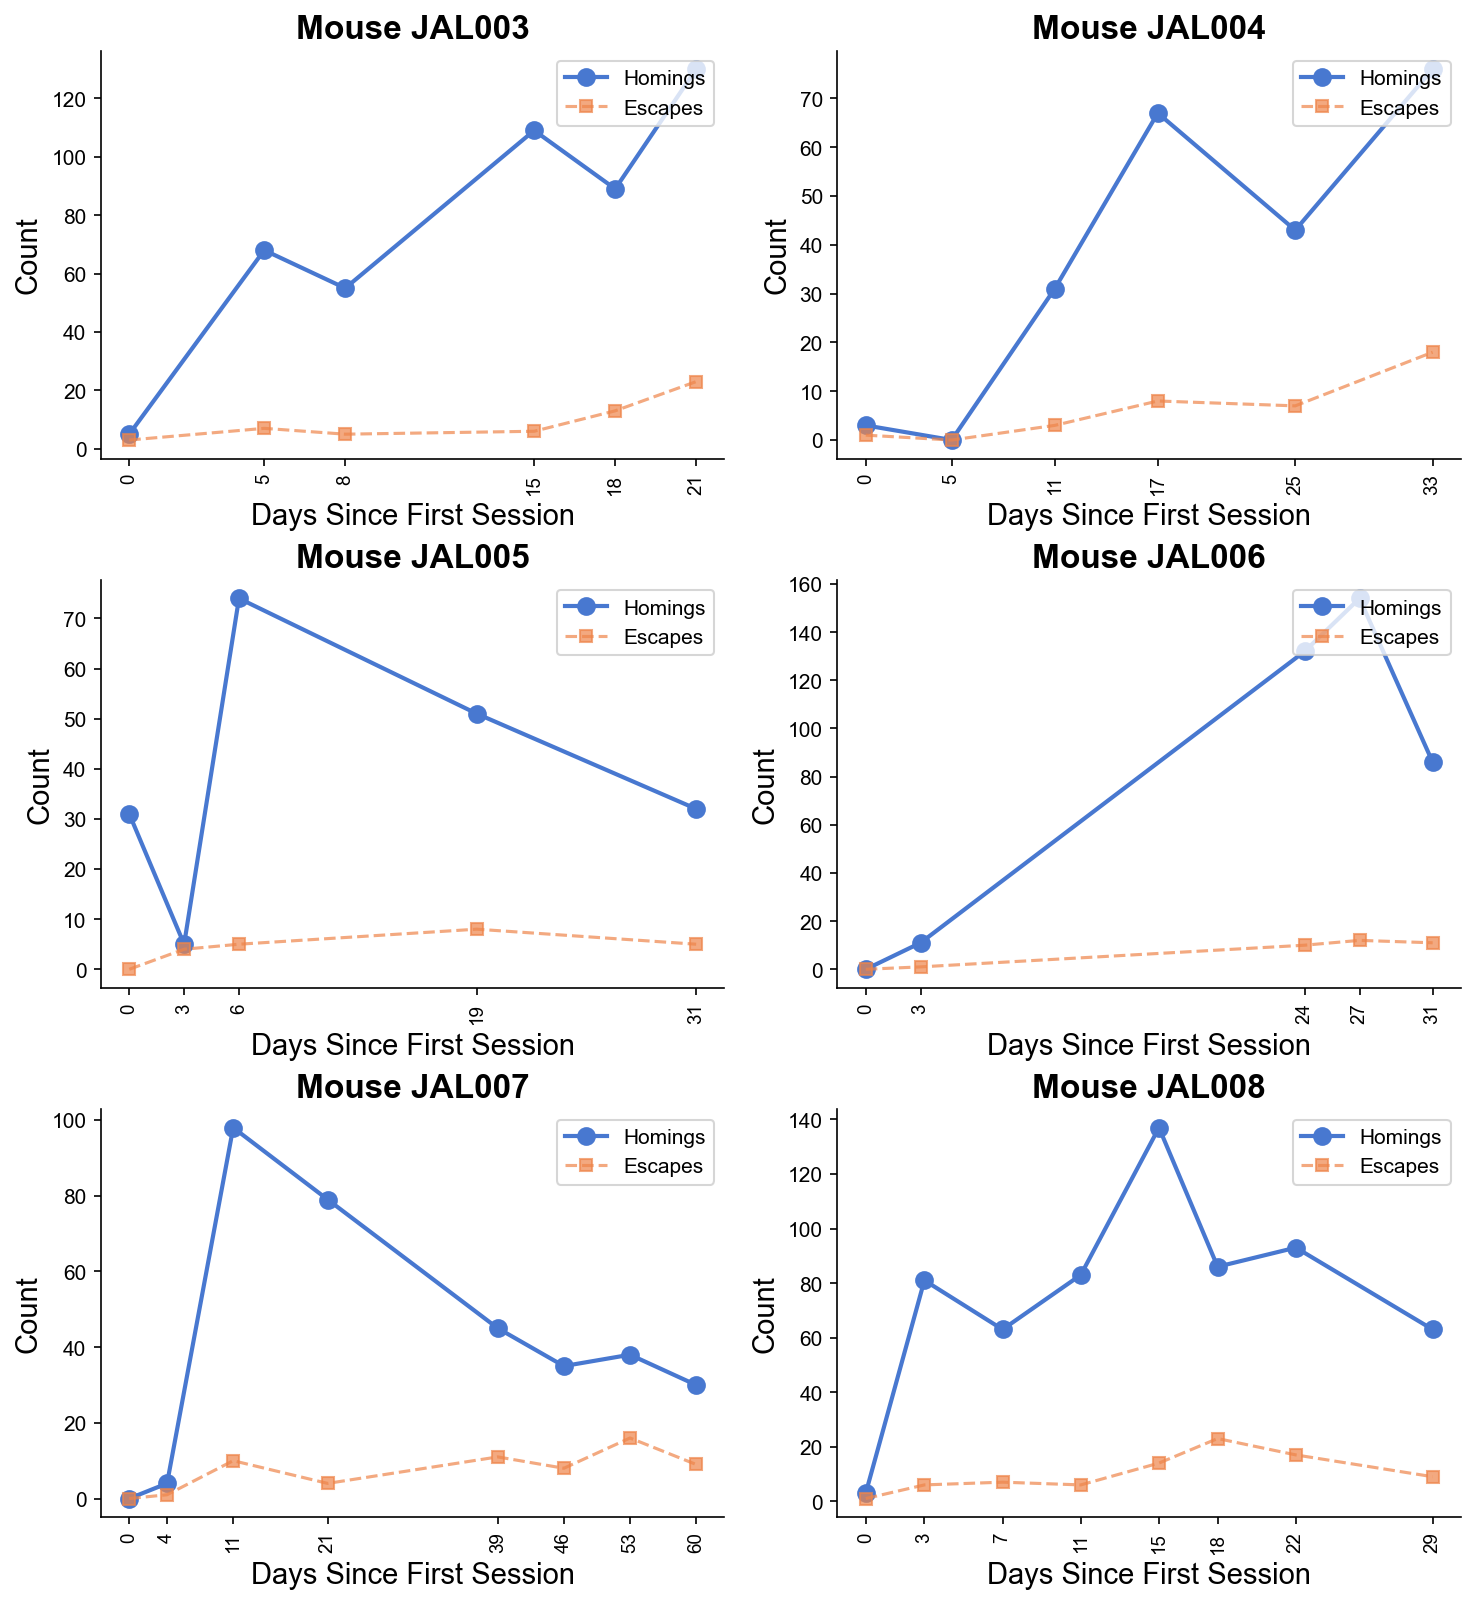

In [19]:
%matplotlib inline
analyze_homings_trend_by_mouse()

# Compare the spatial efficiency between homings and escapes

2025-07-16 15:47:24.072 | INFO     | __main__:compare_spatial_efficiency:7 - Finding all session paths...
2025-07-16 15:47:24.272 | INFO     | __main__:compare_spatial_efficiency:9 - Found 47 session paths
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Summary statistics:
Number of homings with efficiency data: 2158
Number of escapes with efficiency data: 309
Mean homing efficiency: 0.953 ± 0.088
Mean escape efficiency: 0.898 ± 0.149


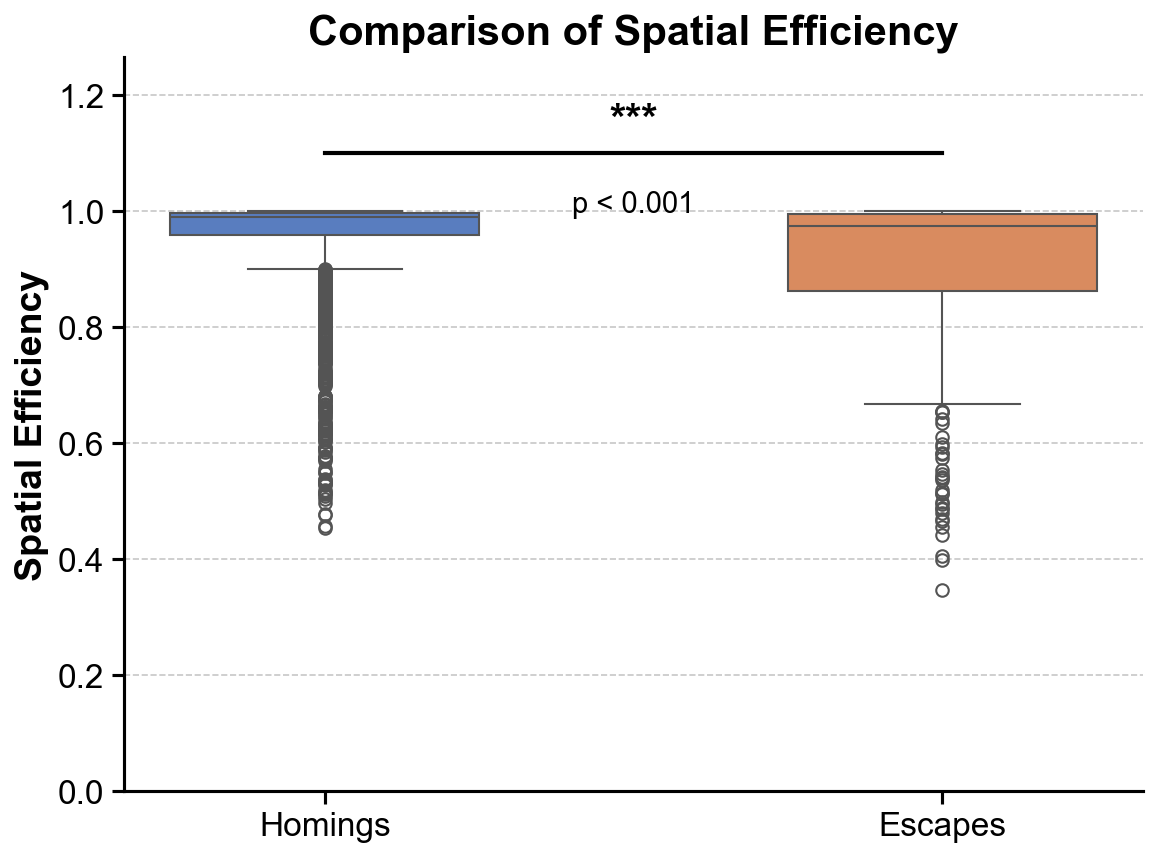

In [20]:
def compare_spatial_efficiency():
    """
    Compare the spatial efficiency of homings vs escapes across all sessions.
    Creates a box plot comparing the distributions and performs statistical analysis.
    """
    # Find all session paths
    logger.info("Finding all session paths...")
    session_paths = find_all_sessions()
    logger.info(f"Found {len(session_paths)} session paths")
    
    # Collect spatial efficiency data for homings and escapes
    homings_efficiency = []
    escapes_efficiency = []
    
    # Process each session
    for session_path in session_paths:
        # Load homings object
        homings_obj = load_homings_object(session_path)
        if homings_obj is not None:
            if hasattr(homings_obj, "spatial_efficiency"):
                homings_efficiency.extend(homings_obj.spatial_efficiency)
            elif hasattr(homings_obj, "path_lengths") and hasattr(homings_obj, "shortest_path_lengths"):
                for shortest, actual in zip(homings_obj.shortest_path_lengths, homings_obj.path_lengths):
                    if actual > 0:
                        homings_efficiency.append(shortest / actual)
        # Load escapes object
        escapes_obj = load_escapes_object(session_path)
        if escapes_obj is not None:
            if hasattr(escapes_obj, "spatial_efficiency"):
                escapes_efficiency.extend(escapes_obj.spatial_efficiency)
            elif hasattr(escapes_obj, "path_lengths") and hasattr(escapes_obj, "shortest_path_lengths"):
                for shortest, actual in zip(escapes_obj.shortest_path_lengths, escapes_obj.path_lengths):
                    if actual > 0:
                        escapes_efficiency.append(shortest / actual)
    
    # Check if we have data to analyze
    if not homings_efficiency or not escapes_efficiency:
        logger.error("No spatial efficiency data found for homings and/or escapes")
        print("\nPlease check if your objects have spatial_efficiency, path_lengths, or shortest_path_lengths attributes")
        return None, None
    
    # Create DataFrame for plotting
    data = pd.DataFrame({
        "Behavior Type": ["Homings"] * len(homings_efficiency) + ["Escapes"] * len(escapes_efficiency),
        "Spatial Efficiency": homings_efficiency + escapes_efficiency
    })
    
    # Print summary statistics
    print("Summary statistics:")
    print(f"Number of homings with efficiency data: {len(homings_efficiency)}")
    print(f"Number of escapes with efficiency data: {len(escapes_efficiency)}")
    print(f"Mean homing efficiency: {np.mean(homings_efficiency):.3f} ± {np.std(homings_efficiency):.3f}")
    print(f"Mean escape efficiency: {np.mean(escapes_efficiency):.3f} ± {np.std(escapes_efficiency):.3f}")
    
    # Set publication-quality plot parameters
    plt.rcParams.update({
        "font.size": 16,
        "font.family": "Arial",
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "savefig.dpi": 300,
        "figure.dpi": 150
    })
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create box plot only (no swarm/individual points)
    sns.boxplot(x="Behavior Type", y="Spatial Efficiency", data=data, 
                palette=["#4878D0", "#EE854A"], width=0.5, ax=ax)
    
    # Perform statistical test (Mann-Whitney U test for non-parametric comparison)
    from scipy.stats import mannwhitneyu
    stat_result = mannwhitneyu(homings_efficiency, escapes_efficiency)
    p_value = stat_result.pvalue
    
    # Add statistical annotation
    if p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = "n.s."
    
    # Calculate position for significance bar
    y_max = max(np.max(homings_efficiency), np.max(escapes_efficiency)) * 1.1
    ax.plot([0, 1], [y_max, y_max], 'k-', linewidth=2)
    ax.text(0.5, y_max * 1.05, significance, ha='center', va='center', fontsize=20, fontweight='bold')
    
    # Add exact p-value
    p_text = f"p = {p_value:.3f}" if p_value >= 0.001 else "p < 0.001"
    ax.text(0.5, y_max * 0.92, p_text, ha='center', va='center', fontsize=14)
    
    # Set axis labels and title
    ax.set_ylabel("Spatial Efficiency", fontweight='bold')
    ax.set_xlabel("")
    ax.set_title("Comparison of Spatial Efficiency", fontweight="bold")
    
    # Set y-axis limits with some padding
    ax.set_ylim(0, y_max * 1.15)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=6)
    
    # Add grid lines for y-axis only
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    
    # Tight layout to maximize figure space
    plt.tight_layout()
    
    # Save the figure with high resolution
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, "spatial_efficiency_comparison.eps"), format='eps', bbox_inches='tight')
    plt.savefig(os.path.join(save_path, "spatial_efficiency_comparison.png"), format='png', bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(save_path, "spatial_efficiency_comparison.pdf"), format='pdf', bbox_inches='tight')
    
    plt.show()
    
    return homings_efficiency, escapes_efficiency

# Run the analysis
homings_eff, escapes_eff = compare_spatial_efficiency()